In [38]:
# =============================================================================
# SETUP Y CONFIGURACIÓN
# =============================================================================
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import json
import pickle
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from joblib import load
import warnings
warnings.filterwarnings('ignore')

# Path setup
BASE_DIR = Path.cwd().parents[1]
sys.path.append(str(BASE_DIR / 'src'))

from config import PROCESSED_DIR

MODELS_DIR = BASE_DIR / 'models'
FINAL_DIR = PROCESSED_DIR / 'final_modeling'

# Commodities y horizonte
TARGET_COMMODITIES = ['Corn', 'Soybeans', 'Wheat']
HORIZON = 't21'  # 21 días
HORIZON_DAYS = 21

print(f"✓ Base directory: {BASE_DIR}")
print(f"✓ Models directory: {MODELS_DIR}")

✓ Base directory: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal
✓ Models directory: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\models


## 2. Carga de Datos de Mercado

In [39]:
# =============================================================================
# CARGA DE DATOS REALES
# =============================================================================

# Dataset con features para LASSO
df_features = pd.read_csv(
    PROCESSED_DIR / 'features_final_modeling.csv', 
    parse_dates=['date']
)
df_features = df_features.drop_duplicates(subset=['date'], keep='first')
df_features = df_features.sort_values('date').reset_index(drop=True)

print(f"✓ Datos cargados: {len(df_features):,} observaciones")
print(f"  Rango: {df_features['date'].min().date()} a {df_features['date'].max().date()}")

# Últimos precios disponibles
print("\n📊 PRECIOS ACTUALES (último dato disponible):")
print("="*50)
ultimo_dato = df_features[['date', 'Corn', 'Soybeans', 'Wheat']].tail(1)
fecha_actual = ultimo_dato['date'].values[0]

for commodity in TARGET_COMMODITIES:
    precio = ultimo_dato[commodity].values[0]
    print(f"  {commodity:12}: ${precio:,.2f} USD/bushel")

print(f"\n  Fecha: {pd.Timestamp(fecha_actual).strftime('%Y-%m-%d')}")

✓ Datos cargados: 6,731 observaciones
  Rango: 2000-01-03 a 2025-11-10

📊 PRECIOS ACTUALES (último dato disponible):
  Corn        : $428.50 USD/bushel
  Soybeans    : $1,124.75 USD/bushel
  Wheat       : $532.50 USD/bushel

  Fecha: 2025-11-10


## 3. Carga de Modelos LASSO

In [40]:
# =============================================================================
# CARGA DE MODELOS LASSO Y SCALERS
# =============================================================================

print("Cargando modelos LASSO...")

# Cargar modelos
lasso_models = {}
for commodity in TARGET_COMMODITIES:
    model_path = MODELS_DIR / f'lasso_{commodity.lower()}_{HORIZON}.joblib'
    if model_path.exists():
        lasso_models[commodity] = load(model_path)
        n_features = np.sum(np.abs(lasso_models[commodity].coef_[0]) > 1e-10)
        print(f"  ✓ {commodity}: {n_features} features no-zero")
    else:
        print(f"  ⚠️ {commodity}: Modelo no encontrado en {model_path}")

# Cargar scalers y feature lists
scalers_path = MODELS_DIR / 'lasso_scalers.pkl'
if scalers_path.exists():
    with open(scalers_path, 'rb') as f:
        lasso_production = pickle.load(f)
    print("\n✓ Scalers y features cargados")
    
    # Mostrar info
    for commodity in TARGET_COMMODITIES:
        if commodity in lasso_production and HORIZON in lasso_production[commodity]:
            info = lasso_production[commodity][HORIZON]
            print(f"  {commodity}: {info['n_features']} features, C={info['best_C']}")
else:
    print(f"⚠️ No se encontró {scalers_path}")
    print("   Ejecuta primero 4.2-logit-lasso-optimized.ipynb")

Cargando modelos LASSO...
  ✓ Corn: 44 features no-zero
  ✓ Soybeans: 99 features no-zero
  ✓ Wheat: 90 features no-zero

✓ Scalers y features cargados
  Corn: 465 features, C=0.01
  Soybeans: 106 features, C=0.5
  Wheat: 108 features, C=0.1


## 4. Función de Predicción LASSO

In [41]:
# =============================================================================
# FUNCIÓN DE PREDICCIÓN LASSO (ACTUALIZADA para polynomial features)
# =============================================================================

def predict_lasso(df, commodity, model, scaler, base_features, poly_transformer=None):
    """
    Genera predicción LASSO para un commodity usando los últimos datos.
    SOPORTA polynomial features si poly_transformer es proporcionado.
    
    Parameters:
    -----------
    df: DataFrame con features
    commodity: 'Corn', 'Soybeans', 'Wheat'
    model: Modelo LASSO entrenado
    scaler: StandardScaler entrenado
    base_features: Lista de features BASE (antes de poly)
    poly_transformer: PolynomialFeatures (opcional, para commodities como Corn)
    
    Returns:
    --------
    prob_sube: Probabilidad de que el precio suba en 21 días
    """
    # Obtener última fila
    last_row = df.iloc[-1:].copy()
    
    # Extraer features base (solo las que existen)
    available_features = [f for f in base_features if f in df.columns]
    X = last_row[available_features].copy()
    
    # Manejar NaN
    X = X.fillna(X.median())
    
    # Escalar PRIMERO
    X_scaled = scaler.transform(X)
    
    # Aplicar polynomial features SI corresponde
    if poly_transformer is not None:
        X_scaled = poly_transformer.transform(X_scaled)
    
    # Predecir probabilidad
    prob_sube = model.predict_proba(X_scaled)[0, 1]
    
    return prob_sube


def predict_lasso_series(df, commodity, model, scaler, base_features, poly_transformer=None):
    """
    Genera predicciones LASSO para toda la serie (para backtest).
    SOPORTA polynomial features.
    """
    available_features = [f for f in base_features if f in df.columns]
    X = df[available_features].copy()
    
    # Manejar NaN
    X = X.fillna(X.median())
    
    # Escalar
    X_scaled = scaler.transform(X)
    
    # Aplicar polynomial features SI corresponde
    if poly_transformer is not None:
        X_scaled = poly_transformer.transform(X_scaled)
    
    # Predecir probabilidades
    probs = model.predict_proba(X_scaled)[:, 1]
    
    return probs


print("✓ Funciones de predicción LASSO definidas (con soporte para polynomial features)")

✓ Funciones de predicción LASSO definidas (con soporte para polynomial features)


## 5. Predicciones Actuales

In [42]:
# =============================================================================
# PREDICCIONES CON DATOS ACTUALES
# =============================================================================

print("="*70)
print("PREDICCIONES LASSO - PRÓXIMOS 21 DÍAS")
print("="*70)
print(f"Fecha de análisis: {pd.Timestamp(fecha_actual).strftime('%Y-%m-%d')}")
print()

predicciones_lasso = {}

for commodity in TARGET_COMMODITIES:
    if commodity not in lasso_models:
        print(f"⚠️ {commodity}: Modelo no disponible")
        continue
    
    model = lasso_models[commodity]
    info = lasso_production[commodity][HORIZON]
    scaler = info['scaler']
    base_features = info['base_features']  # NUEVO: usar base_features
    poly_transformer = info.get('poly_transformer', None)  # NUEVO: obtener poly_transformer
    
    # Predecir (ahora con poly_transformer si corresponde)
    prob = predict_lasso(df_features, commodity, model, scaler, base_features, poly_transformer)
    precio_actual = df_features[commodity].iloc[-1]
    
    predicciones_lasso[commodity] = {
        'precio_actual': precio_actual,
        'prob_sube': prob,
        'señal': 'ESPERAR ↑' if prob > 0.55 else ('VENDER ↓' if prob < 0.45 else 'NEUTRAL →')
    }
    
    # Mostrar
    poly_str = " (con poly)" if poly_transformer is not None else ""
    print(f"📊 {commodity}{poly_str}:")
    print(f"   Precio actual: ${precio_actual:,.2f}")
    print(f"   P(sube en 21d): {prob:.1%}")
    print(f"   Señal: {predicciones_lasso[commodity]['señal']}")
    print()

PREDICCIONES LASSO - PRÓXIMOS 21 DÍAS
Fecha de análisis: 2025-11-10

📊 Corn (con poly):
   Precio actual: $428.50
   P(sube en 21d): 98.0%
   Señal: ESPERAR ↑

📊 Soybeans:
   Precio actual: $1,124.75
   P(sube en 21d): 100.0%
   Señal: ESPERAR ↑

📊 Wheat:
   Precio actual: $532.50
   P(sube en 21d): 99.2%
   Señal: ESPERAR ↑



## 6. Backtest: Validación Histórica del Modelo

In [43]:
# =============================================================================
# BACKTEST CON DATOS REALES
# =============================================================================

from sklearn.metrics import roc_auc_score, accuracy_score

print("="*70)
print("BACKTEST - VALIDACIÓN HISTÓRICA LASSO")
print("="*70)

# Período de test: 2023 en adelante
test_start = '2023-01-01'
df_test = df_features[df_features['date'] >= test_start].copy()

print(f"Período de backtest: {test_start} a {df_test['date'].max().date()}")
print(f"Observaciones: {len(df_test):,}")
print()

backtest_results = {}

for commodity in TARGET_COMMODITIES:
    if commodity not in lasso_models:
        continue
    
    model = lasso_models[commodity]
    info = lasso_production[commodity][HORIZON]
    scaler = info['scaler']
    base_features = info['base_features']  # NUEVO: usar base_features
    poly_transformer = info.get('poly_transformer', None)  # NUEVO: obtener poly_transformer
    
    # Crear target real
    df_test[f'{commodity}_future'] = df_test[commodity].shift(-HORIZON_DAYS)
    df_test[f'{commodity}_direction'] = (df_test[f'{commodity}_future'] > df_test[commodity]).astype(float)
    
    # Predicciones (ahora con poly_transformer si corresponde)
    probs = predict_lasso_series(df_test, commodity, model, scaler, base_features, poly_transformer)
    df_test[f'{commodity}_prob'] = probs
    
    # Calcular métricas (excluyendo NaN del target)
    valid_mask = df_test[f'{commodity}_direction'].notna()
    y_true = df_test.loc[valid_mask, f'{commodity}_direction']
    y_prob = df_test.loc[valid_mask, f'{commodity}_prob']
    y_pred = (y_prob > 0.5).astype(int)
    
    auc = roc_auc_score(y_true, y_prob)
    acc = accuracy_score(y_true, y_pred)
    
    backtest_results[commodity] = {
        'auc': auc,
        'accuracy': acc,
        'n_obs': len(y_true)
    }
    
    print(f"{commodity}:")
    print(f"  AUC: {auc:.4f}")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Observaciones: {len(y_true):,}")
    print()

BACKTEST - VALIDACIÓN HISTÓRICA LASSO
Período de backtest: 2023-01-01 a 2025-11-10
Observaciones: 744

Corn:
  AUC: 0.6906
  Accuracy: 0.5148
  Observaciones: 744

Soybeans:
  AUC: 0.5824
  Accuracy: 0.4530
  Observaciones: 744

Wheat:
  AUC: 0.5715
  Accuracy: 0.4772
  Observaciones: 744



In [44]:
# =============================================================================
# SIMULACIÓN DE ESTRATEGIA DE COMERCIALIZACIÓN
# =============================================================================

def simulate_trading_strategy(df, commodity, prob_col, threshold_wait=0.55, threshold_sell=0.45):
    """
    Simula estrategia de trading basada en señales del modelo.
    
    Estrategia:
    - prob > threshold_wait: ESPERAR (precio va a subir)
    - prob < threshold_sell: VENDER (precio va a bajar)
    - else: HOLD (sin señal clara)
    """
    df_sim = df[['date', commodity, prob_col, f'{commodity}_direction']].copy()
    df_sim = df_sim.dropna()
    
    # Señales
    df_sim['signal'] = 'HOLD'
    df_sim.loc[df_sim[prob_col] > threshold_wait, 'signal'] = 'WAIT'
    df_sim.loc[df_sim[prob_col] < threshold_sell, 'signal'] = 'SELL'
    
    # Calcular retorno a 21 días
    df_sim['future_price'] = df_sim[commodity].shift(-HORIZON_DAYS)
    df_sim['return_21d'] = (df_sim['future_price'] - df_sim[commodity]) / df_sim[commodity] * 100
    df_sim = df_sim.dropna(subset=['return_21d'])
    
    # Analizar por señal
    results = df_sim.groupby('signal').agg({
        'return_21d': ['mean', 'std', 'count'],
        f'{commodity}_direction': 'mean'
    }).round(3)
    
    return results, df_sim


print("="*70)
print("ANÁLISIS DE ESTRATEGIA DE COMERCIALIZACIÓN")
print("="*70)

for commodity in TARGET_COMMODITIES:
    if f'{commodity}_prob' not in df_test.columns:
        continue
    
    results, df_sim = simulate_trading_strategy(
        df_test, commodity, f'{commodity}_prob'
    )
    
    print(f"\n📊 {commodity}:")
    print(results)
    print(f"\nInterpretación:")
    print("  - WAIT: Días donde el modelo sugiere esperar (prob > 55%)")
    print("  - SELL: Días donde el modelo sugiere vender (prob < 45%)")
    print("  - HOLD: Sin señal clara (45% < prob < 55%)")

ANÁLISIS DE ESTRATEGIA DE COMERCIALIZACIÓN

📊 Corn:
       return_21d               Corn_direction
             mean     std count           mean
signal                                        
HOLD        0.193  10.938   110          0.382
SELL       -4.732  11.592   157          0.261
WAIT        0.521   9.176   456          0.524

Interpretación:
  - WAIT: Días donde el modelo sugiere esperar (prob > 55%)
  - SELL: Días donde el modelo sugiere vender (prob < 45%)
  - HOLD: Sin señal clara (45% < prob < 55%)

📊 Soybeans:
       return_21d               Soybeans_direction
             mean     std count               mean
signal                                            
HOLD        2.167  11.398     6              0.667
SELL       -3.758   5.496    32              0.062
WAIT       -0.437   8.512   685              0.442

Interpretación:
  - WAIT: Días donde el modelo sugiere esperar (prob > 55%)
  - SELL: Días donde el modelo sugiere vender (prob < 45%)
  - HOLD: Sin señal clara (45%

## 7. Visualización de Predicciones

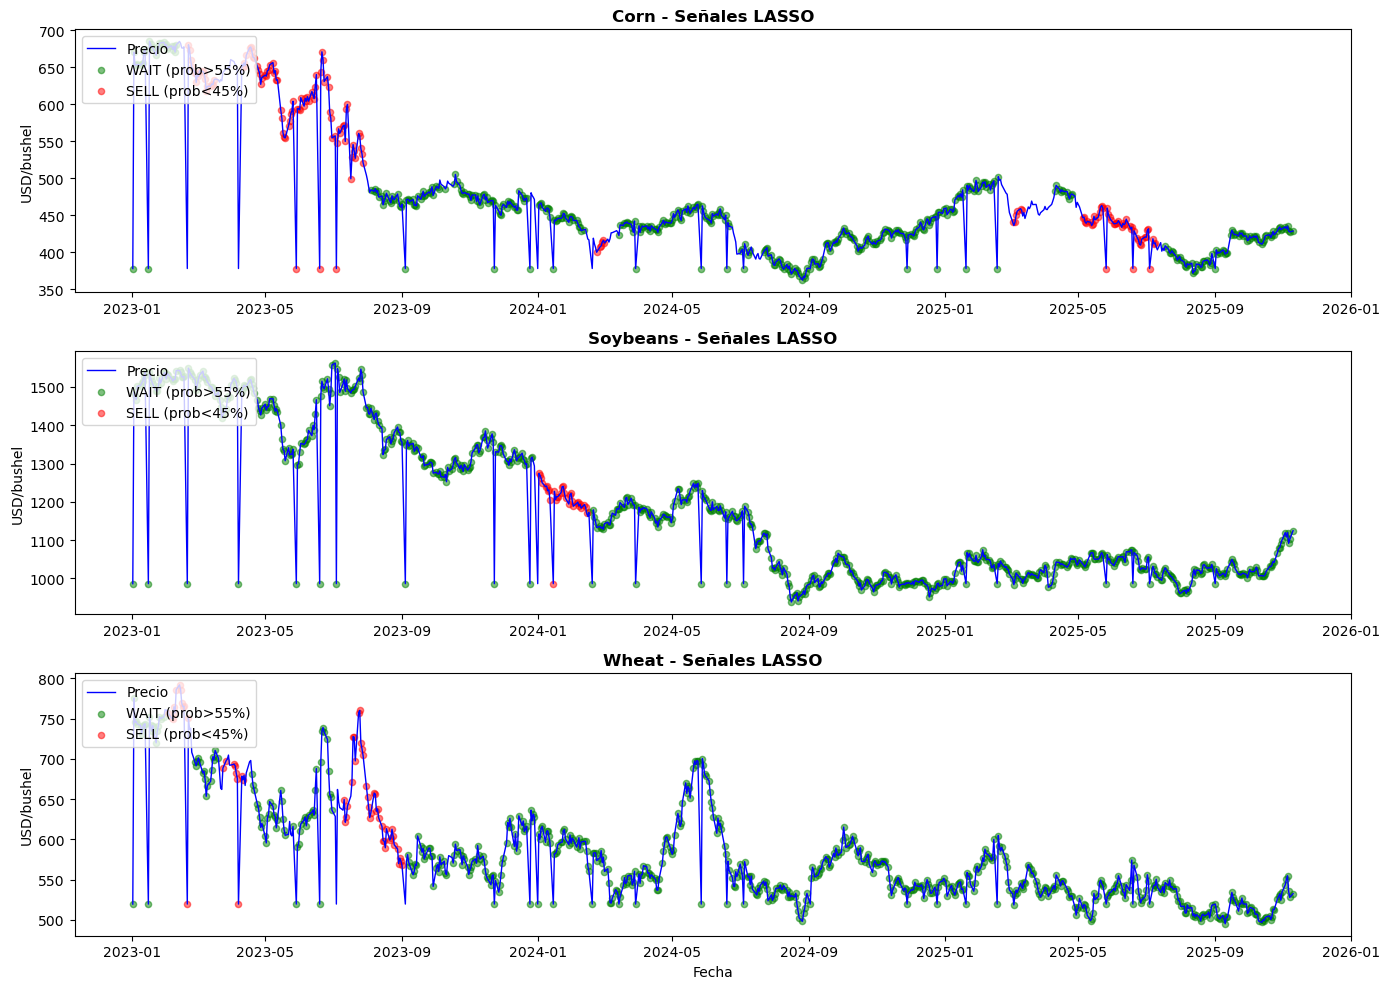

✓ Visualización completada


In [45]:
# =============================================================================
# VISUALIZACIÓN
# =============================================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for idx, commodity in enumerate(TARGET_COMMODITIES):
    if f'{commodity}_prob' not in df_test.columns:
        continue
    
    ax = axes[idx]
    
    # Precio
    ax.plot(df_test['date'], df_test[commodity], 'b-', linewidth=1, label='Precio')
    
    # Marcar señales de WAIT (verde) y SELL (rojo)
    wait_mask = df_test[f'{commodity}_prob'] > 0.55
    sell_mask = df_test[f'{commodity}_prob'] < 0.45
    
    ax.scatter(df_test.loc[wait_mask, 'date'], df_test.loc[wait_mask, commodity],
               color='green', alpha=0.5, s=20, label='WAIT (prob>55%)')
    ax.scatter(df_test.loc[sell_mask, 'date'], df_test.loc[sell_mask, commodity],
               color='red', alpha=0.5, s=20, label='SELL (prob<45%)')
    
    ax.set_title(f'{commodity} - Señales LASSO', fontweight='bold')
    ax.set_ylabel('USD/bushel')
    ax.legend(loc='upper left')
    ax.grid(False)

axes[-1].set_xlabel('Fecha')
plt.tight_layout()
plt.show()

print("✓ Visualización completada")

## 8. Resumen Ejecutivo

In [46]:
# =============================================================================
# RESUMEN EJECUTIVO
# =============================================================================

print("="*70)
print("RESUMEN EJECUTIVO - CONSULTORA AGRÍCOLA (LASSO)")
print("="*70)

print(f"\n📅 Fecha de análisis: {pd.Timestamp(fecha_actual).strftime('%Y-%m-%d')}")
print(f"📊 Modelo: Logistic Regression con LASSO (L1)")
print(f"⏱️ Horizonte: {HORIZON_DAYS} días")

print("\n" + "="*70)
print("PREDICCIONES ACTUALES")
print("="*70)

for commodity, pred in predicciones_lasso.items():
    print(f"\n{commodity}:")
    print(f"  Precio actual: ${pred['precio_actual']:,.2f}")
    print(f"  Probabilidad suba: {pred['prob_sube']:.1%}")
    print(f"  Recomendación: {pred['señal']}")

print("\n" + "="*70)
print("VALIDACIÓN HISTÓRICA (2023+)")
print("="*70)

for commodity, results in backtest_results.items():
    print(f"\n{commodity}:")
    print(f"  AUC-ROC: {results['auc']:.4f}")
    print(f"  Accuracy: {results['accuracy']:.1%}")

print("\n" + "="*70)
print("DISCLAIMER")
print("="*70)
print("Las predicciones son orientativas y no constituyen asesoramiento")
print("financiero. Los modelos tienen limitaciones inherentes y los")
print("mercados de commodities son altamente volátiles.")

RESUMEN EJECUTIVO - CONSULTORA AGRÍCOLA (LASSO)

📅 Fecha de análisis: 2025-11-10
📊 Modelo: Logistic Regression con LASSO (L1)
⏱️ Horizonte: 21 días

PREDICCIONES ACTUALES

Corn:
  Precio actual: $428.50
  Probabilidad suba: 98.0%
  Recomendación: ESPERAR ↑

Soybeans:
  Precio actual: $1,124.75
  Probabilidad suba: 100.0%
  Recomendación: ESPERAR ↑

Wheat:
  Precio actual: $532.50
  Probabilidad suba: 99.2%
  Recomendación: ESPERAR ↑

VALIDACIÓN HISTÓRICA (2023+)

Corn:
  AUC-ROC: 0.6906
  Accuracy: 51.5%

Soybeans:
  AUC-ROC: 0.5824
  Accuracy: 45.3%

Wheat:
  AUC-ROC: 0.5715
  Accuracy: 47.7%

DISCLAIMER
Las predicciones son orientativas y no constituyen asesoramiento
financiero. Los modelos tienen limitaciones inherentes y los
mercados de commodities son altamente volátiles.
